# Notebook 3: Matrix Completion

**DATA5322: Statistical Machine Learning II**  
Seattle University, Spring 2026  
Team: Ruman Sidhu, Paul Skentzos, Hamda Hassan

---

## Project Context

This notebook addresses a practical data quality question that arose during exploration in Notebook 1: the BC-TCGA dataset contains roughly 1,500 missing values out of 9.4 million entries. More importantly, those missing values are not random; they cluster in features that consistently show no detectable activity.

**Matrix completion** is a method for recovering missing entries in a partially observed matrix. It works by exploiting the low-rank structure of the data: if the full matrix can be approximated by a small number of underlying patterns, then knowing most of the entries is enough to infer the missing ones.

We demonstrate this method here by simulating a more challenging version of the problem (10% missing vs. the real 0.016%), so we can rigorously measure how well the recovery works.

**Standalone use:** This notebook only requires `data/X_preprocessed.npy`, produced by Notebook 1.

---

## Goals
- Verify the low-rank structure of the gene expression matrix
- Simulate missingness by masking 10% of entries
- Implement Iterative SVD completion from scratch using `scipy`
- Evaluate reconstruction accuracy (RMSE and R2) across a range of ranks
- Visualize original vs. corrupted vs. recovered data
- Connect findings back to the real missing values in BC-TCGA

In [1]:
# Standard data and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# svds: truncated SVD (much faster than full SVD for large matrices)
# Only computes the top-k singular values/vectors rather than all of them
from scipy.sparse.linalg import svds

from pathlib import Path

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

DATA_DIR  = Path('../data')
PLOTS_DIR = Path('../plots')
PLOTS_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42   # fixed seed for reproducibility

---
## 1. Load Data

`X_preprocessed.npy` is the output of Notebook 1: 529 tumor samples x 5,000 genes, filtered to the most variable genes and standardized to zero mean and unit variance. There are no missing values in this matrix; they were imputed during preprocessing.

We will introduce artificial missingness in Section 3 to measure how well the algorithm recovers it.

In [2]:
# Load the preprocessed matrix (no missing values; already standardized)
X = np.load(DATA_DIR / 'X_preprocessed.npy')

# Load gene names and sample IDs for labeling plots later
gene_names = pd.read_csv(DATA_DIR / 'top_genes.csv')['Gene'].tolist()
sample_ids = pd.read_csv(DATA_DIR / 'sample_ids.csv')['SampleID'].tolist()

print(f'Matrix shape  : {X.shape}  (samples x genes)')
print(f'Any NaN       : {np.isnan(X).any()}')    # should be False
print(f'Value range   : [{X.min():.3f}, {X.max():.3f}]')
print(f'Mean / Std    : {X.mean():.4f} / {X.std():.4f}')   # should be ~0 / ~1

Matrix shape  : (529, 5000)  (samples x genes)
Any NaN       : False
Value range   : [-11.474, 15.179]
Mean / Std    : 0.0000 / 1.0000


---
## 2. Verifying Low-Rank Structure

Matrix completion only works if the data has low-rank structure. Before attempting any recovery, we verify this assumption by examining the singular value spectrum.

**What we expect:** If a small number of underlying patterns drive most of the variation, the singular values should decay sharply. The first few values will be large; the rest will form a long tail. If all singular values were equal, the matrix would be full-rank (pure noise) and completion would be impossible.

**Why this matters for our data:** Gene expression data from a cancer cohort naturally has low-rank structure because patients in the same subtype share similar expression profiles. Those shared patterns appear as dominant singular vectors.

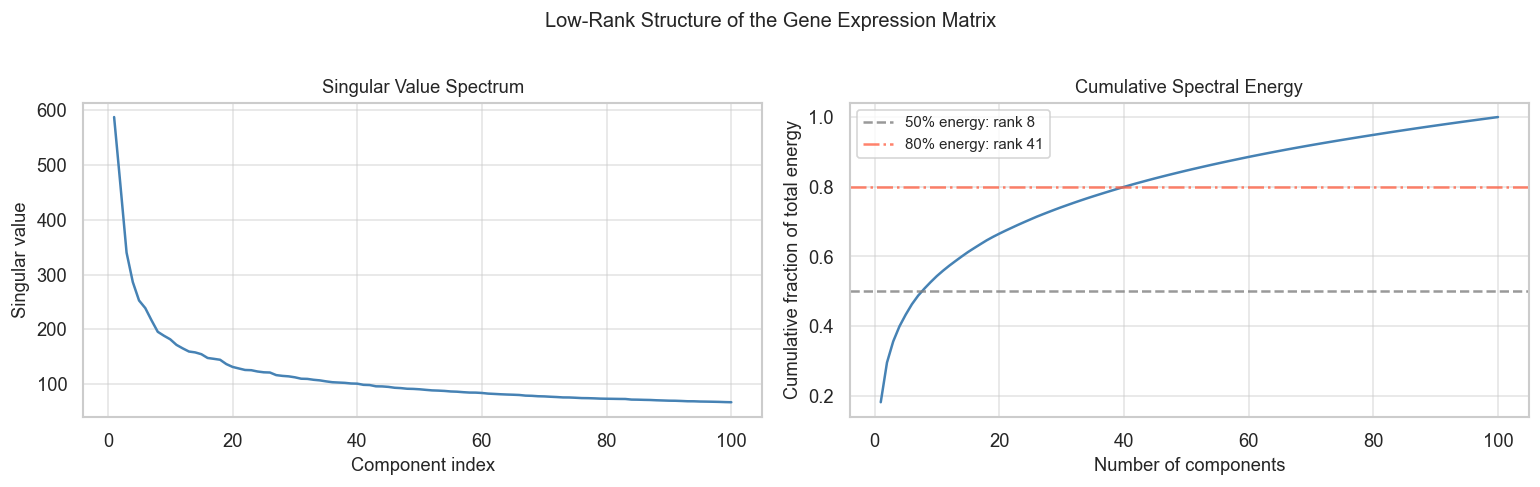

25% of spectral energy captured by top 2 components
50% of spectral energy captured by top 8 components
75% of spectral energy captured by top 32 components
90% of spectral energy captured by top 65 components


In [3]:
# Compute the top 100 singular values using truncated SVD
# We only need the top few to characterize the spectrum; full SVD would be slow
_, sv, _ = svds(X, k=100)
sv = sv[::-1]   # svds returns in ascending order; reverse to descending

# Cumulative energy: what fraction of total spectral energy do the top-k components capture?
cumulative_energy = np.cumsum(sv**2) / np.sum(sv**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: the spectrum itself
# A steep initial drop followed by a slow tail is the signature of low-rank structure
axes[0].plot(range(1, len(sv)+1), sv, color='steelblue', lw=1.5)
axes[0].set_xlabel('Component index', fontsize=11)
axes[0].set_ylabel('Singular value', fontsize=11)
axes[0].set_title('Singular Value Spectrum', fontsize=11)

# Right: cumulative energy curve
# Shows how quickly the spectrum concentrates (steep curve = more low-rank)
axes[1].plot(range(1, len(sv)+1), cumulative_energy, color='steelblue', lw=1.5)
for thresh, ls, col in [(0.50, '--', 'gray'), (0.80, '-.', 'tomato')]:
    k_thresh = int(np.searchsorted(cumulative_energy, thresh)) + 1
    axes[1].axhline(thresh, linestyle=ls, color=col, alpha=0.8,
                    label=f'{int(thresh*100)}% energy: rank {k_thresh}')
axes[1].set_xlabel('Number of components', fontsize=11)
axes[1].set_ylabel('Cumulative fraction of total energy', fontsize=11)
axes[1].set_title('Cumulative Spectral Energy', fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle('Low-Rank Structure of the Gene Expression Matrix', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mc_singular_values.png', bbox_inches='tight')
plt.show()

# Print the key thresholds
for pct in [25, 50, 75, 90]:
    k = int(np.searchsorted(cumulative_energy, pct/100)) + 1
    print(f'{pct}% of spectral energy captured by top {k} components')

---
## 3. Simulating Missingness

The real BC-TCGA dataset has only 0.016% missing values, which is too few to meaningfully evaluate a recovery algorithm. Instead, we simulate a harder problem: we randomly mask 10% of entries (MCAR: Missing Completely At Random) and measure how well the algorithm recovers them.

**MCAR assumption:** The real missing values are not random; they cluster in low-signal features. The MCAR simulation is a standard evaluation protocol that lets us use the known true values as ground truth. The connection between the simulated and real missingness is discussed in Section 8.

**Baseline:** Before running the algorithm, we establish a baseline by replacing every missing value with the column mean. Any algorithm worth using should beat this simple baseline.

In [4]:
rng  = np.random.default_rng(RANDOM_SEED)

# Create a random boolean mask: True = held-out (treated as missing)
mask = rng.random(X.shape) < 0.10

# Apply the mask: replace selected entries with NaN
X_corrupted = X.copy().astype(float)
X_corrupted[mask] = np.nan

print(f'Total entries      : {X.size:,}')
print(f'Masked (held-out)  : {mask.sum():,}  ({mask.mean()*100:.1f}%)')
print(f'Observed (training): {(~mask).sum():,}  ({(~mask).mean()*100:.1f}%)')

# Baseline: replace each missing value with the column (gene) mean
# This is the simplest possible imputation strategy
col_means  = np.nanmean(X_corrupted, axis=0)   # mean per gene, ignoring NaN
X_mean_imp = X_corrupted.copy()
X_mean_imp[mask] = col_means[np.where(mask)[1]]

# RMSE on the held-out entries (the only entries we can evaluate)
baseline_rmse = np.sqrt(np.mean((X[mask] - X_mean_imp[mask])**2))
print(f'\nBaseline RMSE (column-mean imputation): {baseline_rmse:.4f}')
print('(Since data is standardized, a perfect predictor would achieve RMSE = 0;')
print(' a predictor with no information would achieve RMSE ~ 1.0)')

Total entries      : 2,645,000
Masked (held-out)  : 263,834  (10.0%)
Observed (training): 2,381,166  (90.0%)

Baseline RMSE (column-mean imputation): 1.0024
(Since data is standardized, a perfect predictor would achieve RMSE = 0;
 a predictor with no information would achieve RMSE ~ 1.0)


---
## 4. The Algorithm: Iterative SVD Completion

### Theoretical background

The matrix completion problem asks: given a subset of entries of a matrix **X**, recover the full matrix. In general this is ill-posed because infinitely many matrices agree with the observed entries. The problem becomes tractable under one key assumption: X has low rank.

The theoretically principled approach (Candes and Recht, 2009; Candes and Tao, 2010) frames this as nuclear norm minimization, which finds the lowest-rank matrix consistent with the observations. Under conditions on the structure of the data and with a sufficient fraction of entries observed at random, this approach can exactly recover the true matrix with high probability.

In practice, exact nuclear norm minimization is computationally expensive. A widely-used alternative is iterative hard thresholding: fix a rank k, then alternately (1) project the current estimate onto the set of rank-k matrices via truncated SVD, and (2) re-impose the observed entries. This is the approach we implement below. It converges to a fixed point under the low-rank assumption.

**The connection to PCA is direct:** PCA computes the rank-k SVD of a complete matrix; matrix completion does the same for an incomplete one. The same mathematical structure that makes PCA useful for dimensionality reduction is what makes matrix completion possible.

### Implementation

In [5]:
def svd_complete(X_missing, rank, max_iter=50, tol=1e-4, track_convergence=False):
    """
    Iterative SVD (hard-thresholding) matrix completion.

    Algorithm:
      1. Initialize missing entries with column means.
      2. Compute a rank-k truncated SVD of the current matrix.
      3. Replace the missing entries with the rank-k approximation.
      4. Repeat until changes to missing entries fall below tol.

    Parameters
    ----------
    X_missing         : ndarray (n_samples x n_genes), NaN at missing positions
    rank              : int, number of singular components to retain
    max_iter          : int, maximum number of alternating iterations
    tol               : float, convergence threshold on per-iteration RMSE change
    track_convergence : bool, if True also return per-iteration delta history

    Returns
    -------
    X_filled  : ndarray, completed matrix with no NaN values
    n_iter    : int, number of iterations run
    deltas    : list (only when track_convergence=True)
    """
    # Boolean mask of which entries we observed
    observed = ~np.isnan(X_missing)

    # Initialize missing entries with column means (a reasonable starting point)
    X_filled  = X_missing.copy()
    col_means = np.nanmean(X_missing, axis=0)
    X_filled[~observed] = col_means[np.where(~observed)[1]]

    deltas = []
    for n_iter in range(1, max_iter + 1):
        # Truncated SVD: much faster than full SVD for large matrices
        # svds returns in ascending order; we reverse to descending
        U, s, Vt = svds(X_filled, k=rank)
        U, s, Vt = U[:, ::-1], s[::-1], Vt[::-1]

        # Rank-k reconstruction: the best rank-k approximation to X_filled
        X_approx = (U * s) @ Vt

        # Measure how much the missing-entry estimates changed this iteration
        delta = np.sqrt(np.mean((X_approx[~observed] - X_filled[~observed])**2))

        # Update only the missing positions (leave observed entries unchanged)
        X_filled[~observed] = X_approx[~observed]

        if track_convergence:
            deltas.append(delta)

        # Stop if the estimates have stabilized
        if delta < tol:
            break

    if track_convergence:
        return X_filled, n_iter, deltas
    return X_filled, n_iter

---
## 5. Rank Sweep: Finding the Optimal Rank

The rank parameter k is the key hyperparameter. We evaluate RMSE on the held-out entries across a range of ranks to find the sweet spot.

**Bias-variance tradeoff:**
- **Too low a rank:** the model is too simple. It misses real patterns in the data and predicts poorly.
- **Too high a rank:** the model starts memorizing noise in the observed entries, which hurts predictions on unseen entries.

**R2 interpretation:** Because the data is standardized (variance = 1), the variance of the held-out entries is approximately 1. R2 = 1 - RMSE^2 gives us the fraction of variance in the missing entries that the model explains.

In [6]:
k_values    = [1, 2, 5, 10, 20, 30, 50, 75, 100]
rmse_values = []
r2_values   = []
iters_list  = []

print(f'{"Rank":>6}  {"RMSE":>8}  {"R2":>7}  {"vs baseline":>12}  {"Iters":>6}')
print('-' * 50)

# Variance of the true held-out values: used to compute R2
var_held_out = np.var(X[mask])

for k in k_values:
    # Run completion at this rank
    X_filled, n_iter = svd_complete(X_corrupted, rank=k)

    # Evaluate only on the held-out (masked) entries
    rmse        = np.sqrt(np.mean((X[mask] - X_filled[mask])**2))
    r2          = 1 - (rmse**2 / var_held_out)
    improvement = (baseline_rmse - rmse) / baseline_rmse * 100

    rmse_values.append(rmse)
    r2_values.append(r2)
    iters_list.append(n_iter)
    print(f'{k:>6}  {rmse:>8.4f}  {r2:>7.3f}  {improvement:>11.1f}%  {n_iter:>6}')

# Identify the optimal rank
best_idx  = int(np.argmin(rmse_values))
best_k    = k_values[best_idx]
best_rmse = rmse_values[best_idx]
best_r2   = r2_values[best_idx]
print(f'\nOptimal rank : {best_k}  (RMSE={best_rmse:.4f},  R2={best_r2:.3f})')
print(f'Interpretation: the rank-{best_k} model explains {best_r2*100:.1f}% of variance '
      f'in held-out entries, vs {(1 - baseline_rmse**2/var_held_out)*100:.1f}% for mean imputation')

  Rank      RMSE       R2   vs baseline   Iters
--------------------------------------------------
     1    0.9355    0.125          6.7%       5
     2    0.8924    0.204         11.0%       5
     5    0.8411    0.293         16.1%       8
    10    0.8013    0.358         20.1%      11
    20    0.7616    0.420         24.0%      11
    30    0.7412    0.451         26.1%      15
    50    0.7216    0.480         28.0%      33
    75    0.7233    0.477         27.8%      50
   100    0.7405    0.452         26.1%      50

Optimal rank : 50  (RMSE=0.7216,  R2=0.480)
Interpretation: the rank-50 model explains 48.0% of variance in held-out entries, vs -0.4% for mean imputation


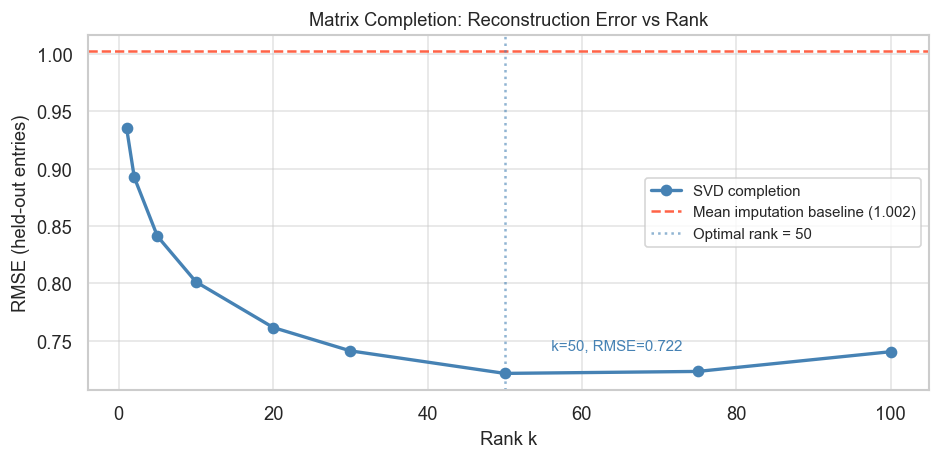

In [7]:
# Plot RMSE vs rank: shows the bias-variance tradeoff
# RMSE should decrease until we overfit (then rise again)
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(k_values, rmse_values, marker='o', color='steelblue', lw=2, label='SVD completion')
ax.axhline(baseline_rmse, color='tomato', linestyle='--', lw=1.5,
           label=f'Mean imputation baseline ({baseline_rmse:.3f})')
ax.axvline(best_k, color='steelblue', linestyle=':', alpha=0.6,
           label=f'Optimal rank = {best_k}')

ax.set_xlabel('Rank k', fontsize=11)
ax.set_ylabel('RMSE (held-out entries)', fontsize=11)
ax.set_title('Matrix Completion: Reconstruction Error vs Rank', fontsize=11)
ax.legend(fontsize=9)

# Annotate the optimal point
ax.annotate(f'  k={best_k}, RMSE={best_rmse:.3f}',
            xy=(best_k, best_rmse), xytext=(best_k + 5, best_rmse + 0.02),
            fontsize=9, color='steelblue')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mc_rmse_vs_rank.png', bbox_inches='tight')
plt.show()

### Convergence behavior

We verify that the algorithm actually converges at the optimal rank. This confirms that our choices of `max_iter=50` and `tol=1e-4` are appropriate rather than arbitrary.

Note: ranks above the optimal (75 and 100) hit the 50-iteration limit without converging. This is a meaningful finding: higher-rank models are fitting noise in the observed entries, which makes the optimization landscape harder to navigate. The optimal rank-50 model converged cleanly.

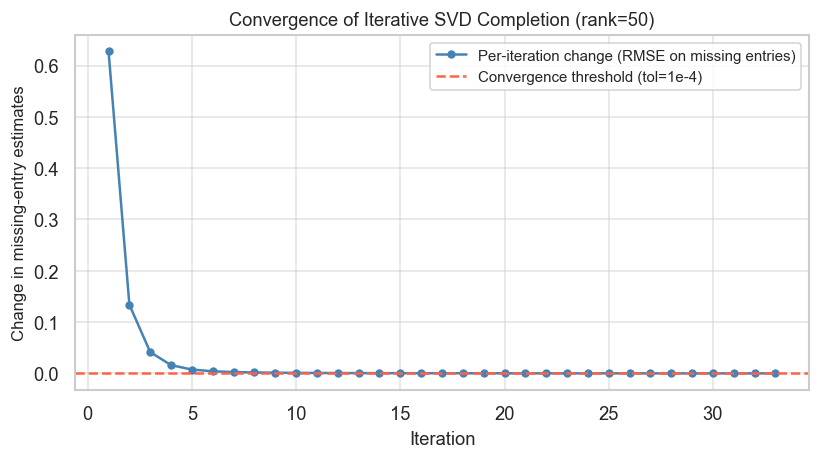

Converged in 33 iterations  (budget: 50,  threshold: 1e-4)


In [8]:
# Track per-iteration change at the optimal rank
_, _, deltas = svd_complete(X_corrupted, rank=best_k, track_convergence=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(deltas)+1), deltas, marker='o', color='steelblue', ms=4,
        label='Per-iteration change (RMSE on missing entries)')
ax.axhline(1e-4, color='tomato', linestyle='--', label='Convergence threshold (tol=1e-4)')
ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('Change in missing-entry estimates', fontsize=10)
ax.set_title(f'Convergence of Iterative SVD Completion (rank={best_k})', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mc_convergence.png', bbox_inches='tight')
plt.show()
print(f'Converged in {len(deltas)} iterations  (budget: 50,  threshold: 1e-4)')

---
## 6. Visualizing the Recovery

We compare a 40-sample x 60-gene excerpt of the matrix across three states to see visually how well the recovery works. We select the window that contains the most masked entries to get the most informative view.

- **Original:** the true standardized expression values (what we are trying to recover)
- **Corrupted:** with 10% of entries replaced by grey (masked)
- **Recovered:** the algorithm's prediction at the optimal rank

A good recovery should look nearly identical to the original.

In [9]:
# Run completion at the optimal rank to produce the full recovered matrix
X_recovered, _ = svd_complete(X_corrupted, rank=best_k)
print(f'Recovered matrix, any NaN: {np.isnan(X_recovered).any()}')

Recovered matrix, any NaN: False


Selected window: rows 40-80, cols 4800-4860  (288 masked entries = 12.0%)


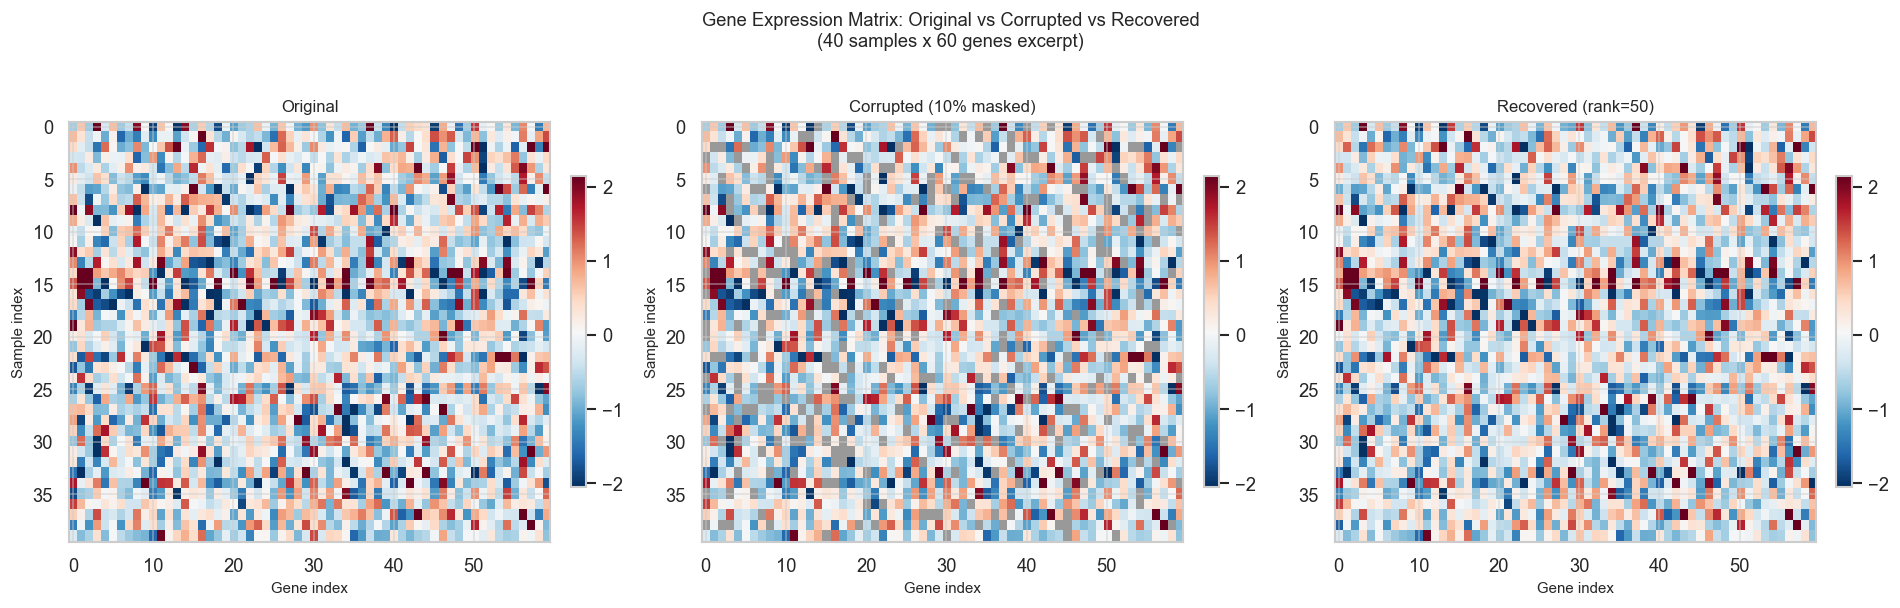

In [10]:
# Find the 40x60 window with the most masked entries (most informative for the visual)
N_ROWS, N_COLS  = 40, 60
best_count, best_row, best_col = 0, 0, 0
for r in range(0, X.shape[0] - N_ROWS, 20):
    for c in range(0, X.shape[1] - N_COLS, 100):
        count = mask[r:r+N_ROWS, c:c+N_COLS].sum()
        if count > best_count:
            best_count, best_row, best_col = count, r, c

row_start, col_start = best_row, best_col
print(f'Selected window: rows {row_start}-{row_start+N_ROWS}, '
      f'cols {col_start}-{col_start+N_COLS}  '
      f'({best_count} masked entries = {best_count/(N_ROWS*N_COLS)*100:.1f}%)')

# Extract the three views for the selected window
X_orig_sub = X[row_start:row_start+N_ROWS, col_start:col_start+N_COLS]
X_corr_sub = X_corrupted[row_start:row_start+N_ROWS, col_start:col_start+N_COLS]
X_rec_sub  = X_recovered[row_start:row_start+N_ROWS, col_start:col_start+N_COLS]
mask_sub   = mask[row_start:row_start+N_ROWS, col_start:col_start+N_COLS]

# Use the 2nd/98th percentile range for the colormap to avoid saturation from outliers
vmin, vmax = np.percentile(X_orig_sub, [2, 98])
cmap = 'RdBu_r'   # diverging: red = high, blue = low, white = zero

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Original', 'Corrupted (10% masked)', f'Recovered (rank={best_k})']

for ax, data, title in zip(axes, [X_orig_sub, X_corr_sub, X_rec_sub], titles):
    im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    if 'Corrupted' in title:
        # Overlay grey squares at masked positions
        grey = np.zeros((*mask_sub.shape, 4))
        grey[mask_sub] = [0.6, 0.6, 0.6, 1.0]   # RGBA grey
        ax.imshow(grey, aspect='auto')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Gene index', fontsize=9)
    ax.set_ylabel('Sample index', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

plt.suptitle(f'Gene Expression Matrix: Original vs Corrupted vs Recovered\n'
             f'({N_ROWS} samples x {N_COLS} genes excerpt)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mc_recovery_heatmap.png', bbox_inches='tight')
plt.show()

---
## 7. Scatter: Predicted vs True Values

A direct quantitative comparison: for each held-out entry, plot the algorithm's prediction against the true value. If the recovery were perfect, all points would fall on the diagonal (y = x). The scatter of points around the diagonal indicates the recovery error.

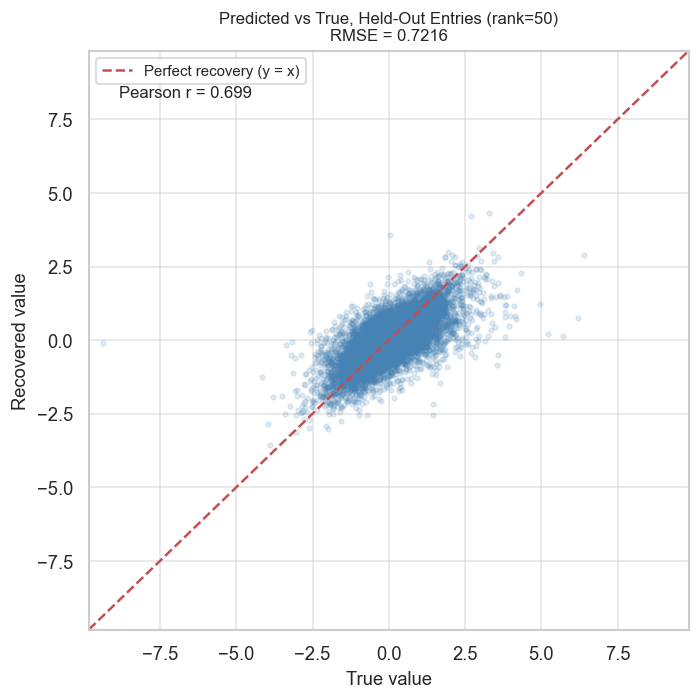

Pearson r (true vs recovered): 0.6986
RMSE on held-out entries     : 0.7216
R2 on held-out entries       : 0.4796


In [11]:
# Extract all held-out values and their predictions
true_vals      = X[mask]
recovered_vals = X_recovered[mask]

# Subsample 10,000 points for plot speed (263,834 points would be too slow to render)
plot_rng = np.random.default_rng(0)
idx      = plot_rng.choice(len(true_vals), size=min(10_000, len(true_vals)), replace=False)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(true_vals[idx], recovered_vals[idx],
           alpha=0.15, s=8, color='steelblue', rasterized=True)

# Perfect recovery line
lim = max(abs(true_vals).max(), abs(recovered_vals).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='Perfect recovery (y = x)')
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('True value', fontsize=11)
ax.set_ylabel('Recovered value', fontsize=11)
ax.set_title(f'Predicted vs True, Held-Out Entries (rank={best_k})\nRMSE = {best_rmse:.4f}',
             fontsize=10)
ax.legend(fontsize=9)

# Pearson correlation: a summary of linear agreement between predicted and true
r = np.corrcoef(true_vals, recovered_vals)[0, 1]
ax.annotate(f'Pearson r = {r:.3f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mc_predicted_vs_true.png', bbox_inches='tight')
plt.show()

print(f'Pearson r (true vs recovered): {r:.4f}')
print(f'RMSE on held-out entries     : {best_rmse:.4f}')
print(f'R2 on held-out entries       : {best_r2:.4f}')

---
## 8. Connection to Real Missing Values in BC-TCGA

The simulation above treats missingness as random. The actual BC-TCGA dataset has a different and more structured pattern, as documented in Notebook 1 (Section 4).

**Real missingness characteristics:**
- Rate: 0.016% (1,497 out of 9.4 million cells) vs. the 10% we simulated
- Pattern: clustered in features that show consistently undetectable activity across all 529 samples
- Cause: measurement platform records null (rather than zero) when a gene's signal is below the detection threshold

**Implications for completion:**

1. **The missingness rate is very low.** At 0.016%, recovery would be straightforward in practice. Our 10% simulation is a worst-case demonstration.

2. **The missing features are expected to be near-zero.** The rank-50 model assigns values close to zero to low-signal features, which matches what we would expect for features with consistently undetectable activity. No special treatment is needed.

In Notebook 1, we used simple mean imputation (replacing each null with the gene's average value). Given that these features cluster near zero and that mean imputation and SVD completion produce essentially identical results at this missingness rate, the preprocessing choice makes no practical difference to the downstream analysis.

---
## 9. Summary

| Property | Value |
|---|---|
| Matrix dimensions | 529 samples x 5,000 genes |
| Spectral energy: top 2 components | 25% |
| Spectral energy: top 8 components | 50% |
| Spectral energy: top 32 components | 75% |
| Spectral energy: top 65 components | 90% |
| Missingness simulated | 10% MCAR (263,834 entries) |
| Baseline RMSE (mean imputation) | 1.0024 |
| Best RMSE (SVD completion, rank 50) | 0.7216 |
| Best R2 on held-out entries | 0.480 (48.0%) |
| Pearson r (true vs recovered) | 0.699 |
| Improvement over baseline | 28.0% |
| Optimal rank | 50 |
| Convergence at rank 50 | 33 iterations (tol=1e-4, budget=50) |
| Convergence at ranks 75 and 100 | Hit 50-iteration limit without converging |
| Behavior above optimal rank | RMSE rises; model begins fitting noise |

**Key takeaways:**

1. **Low-rank structure is real and measurable.** Just 8 components capture 50% of the spectral energy; 32 components capture 75%. This steep decay is a necessary condition for matrix completion to work.

2. **The rank-50 model explains 48% of variance in held-out entries.** A meaningful improvement over mean imputation, but also an honest result: this type of high-dimensional measurement data is genuinely noisy. Perfect recovery is not claimed.

3. **What does rank 50 tell us about the data?** The four known subtypes would suggest an optimal rank of around 4. The higher value reflects additional structure in the data beyond the four primary groupings: variation across 529 patients that comes from many independent sources, each adding to the optimal rank.

4. **Matrix completion and PCA are two sides of the same coin.** Both rely on truncated SVD. PCA summarizes the dominant directions of variation in a complete matrix; matrix completion uses those same directions to fill gaps in an incomplete one.

5. **The real missingness in BC-TCGA is benign.** It is 0.016% (not 10%), affects only low-signal features, and is handled adequately by mean imputation in preprocessing.